# Metrics Module — FL-IDS Pipeline

**Project:** Evaluating Federated Learning for Intrusion Detection in Industrial IoT  
**Module:** `src/metrics.py`  

---

## Purpose

This notebook verifies the metrics utilities and demonstrates how they'll be
used in the full experiment pipeline. The `metrics.py` module is a **post-processing
layer** — it consumes results from `baselines.py` and `federated.py`, computing
derived metrics, statistical tests, and thesis-ready tables.

## What This Notebook Covers

| Step | Description |
|------|------------|
| 1 | Confusion matrix for the centralized baseline |
| 2 | ROC-AUC computation (proposal requirement) |
| 3 | Full classification report (thesis table) |
| 4 | Save/load results to JSON (reproducibility) |
| 5 | Communication cost analysis (using federated result) |
| 6 | Convergence analysis |
| 7 | Rounds-to-target analysis |
| 8 | Comparison table — all methods side by side |
| 9 | Multi-seed aggregation demo |
| 10 | Statistical significance testing |

---
## Step 0 — Imports and Setup

In [1]:
import sys, os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('../src/'))

from metrics import (
    compute_confusion_matrix, compute_roc_auc, full_classification_report,
    aggregate_seeds, comm_cost_summary, rounds_to_target,
    convergence_summary, build_comparison_table, print_comparison_table,
    pairwise_significance, save_results, load_results, experiment_summary,
)
from baselines import run_centralized, run_local_only
from federated import run_federated, evaluate_model
from model import create_model, set_model_params
from preprocessing import load_processed_data, apply_scaler, get_class_weights
from sklearn.model_selection import train_test_split

DATA_PATH = "../data/processed/datasense_preprocessed.csv"
PARTITION_PATH = "../data/partitions/iid_K5_seed42.json"
LABEL_CFG_PATH = "../data/processed/label_config.json"
RESULTS_DIR = "../results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_, LABEL_NAMES = get_class_weights(LABEL_CFG_PATH)
CLASS_NAMES = [LABEL_NAMES[i] for i in range(8)]

print(f"Device: {DEVICE}")
print(f"Classes: {CLASS_NAMES}")

Device: cpu
Classes: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']


---
## Step 0b — Run baselines and a quick FL experiment

We need results to demonstrate metrics on. Run the centralized baseline
(with the winning Adam config) and a short FL experiment.

In [2]:
# Centralized baseline (winning config from tuning)
cent_results = run_centralized(
    data_path=DATA_PATH,
    epochs=100,
    lr=0.001,
    batch_size=64,
    optimizer_type="adam",
    device=DEVICE,
    seed=42,
    verbose=True,
)

CENTRALIZED BASELINE (upper bound)
Loaded: 30,030 samples, 17 features
Train: 24,024  |  Test: 6,006
Training for 100 epochs (ADAM, lr=0.001, batch=64)
──────────────────────────────────────────────────────────────────────
  [Centralized] Epoch   1/100  loss=1.3608  acc=0.7388  f1=0.6257
  [Centralized] Epoch  10/100  loss=0.5477  acc=0.8467  f1=0.7497
  [Centralized] Epoch  20/100  loss=0.4462  acc=0.8881  f1=0.8243
  [Centralized] Epoch  30/100  loss=0.4073  acc=0.8988  f1=0.8409
  [Centralized] Epoch  40/100  loss=0.3857  acc=0.8866  f1=0.8201
  [Centralized] Epoch  50/100  loss=0.3527  acc=0.8868  f1=0.8096
  [Centralized] Epoch  60/100  loss=0.3447  acc=0.8963  f1=0.8278
  [Centralized] Epoch  70/100  loss=0.3395  acc=0.9086  f1=0.8551
  [Centralized] Epoch  80/100  loss=0.3323  acc=0.9061  f1=0.8537
  [Centralized] Epoch  90/100  loss=0.3168  acc=0.9121  f1=0.8643
  [Centralized] Epoch 100/100  loss=0.3204  acc=0.9177  f1=0.8729
  [Centralized] Best F1: 0.8846 at epoch 98
───────

In [3]:
# Local-only baseline
local_results = run_local_only(
    data_path=DATA_PATH,
    partition_path=PARTITION_PATH,
    epochs=50,
    lr=0.01,
    batch_size=64,
    device=DEVICE,
    seed=42,
    verbose=True,
)

LOCAL-ONLY BASELINE (lower bound)
Loaded: 30,030 samples, 5 clients (iid)
Global test set: 6,006 samples
──────────────────────────────────────────────────────────────────────

Client 0: 4749 samples, 8 classes present
  [Client 0] Epoch   1/50  loss=2.3601  acc=0.4965  f1=0.3805
  [Client 0] Epoch   5/50  loss=1.2893  acc=0.6778  f1=0.5595
  [Client 0] Epoch  10/50  loss=1.0744  acc=0.6655  f1=0.5537
  [Client 0] Epoch  15/50  loss=0.9974  acc=0.7208  f1=0.5971
  [Client 0] Epoch  20/50  loss=0.9844  acc=0.7393  f1=0.6190
  [Client 0] Epoch  25/50  loss=0.8895  acc=0.7589  f1=0.6269
  [Client 0] Epoch  30/50  loss=0.8638  acc=0.7526  f1=0.6235
  [Client 0] Epoch  35/50  loss=0.8453  acc=0.7567  f1=0.6442
  [Client 0] Epoch  40/50  loss=0.8259  acc=0.7739  f1=0.6574
  [Client 0] Epoch  45/50  loss=0.7854  acc=0.7428  f1=0.6256
  [Client 0] Epoch  50/50  loss=0.7768  acc=0.7522  f1=0.6315
  [Client 0] Best F1: 0.6586 at epoch 42
  → Client 0 final: acc=0.7522  f1=0.6315

Client 1: 4812 

In [4]:
# Quick FL experiment (short R=20 for demo, not full experiment)
fl_results = run_federated(
    data_path=DATA_PATH,
    partition_path=PARTITION_PATH,
    num_rounds=20,
    local_epochs=5,
    lr=0.01,
    batch_size=64,
    participation_fraction=1.0,
    device=DEVICE,
    seed=42,
    verbose=True,
)

Loaded: 30,030 samples, 5 clients (iid)
Global test set: 6,006 samples
Created 5 clients (samples: [4749, 4812, 4807, 4791, 4865])
Model size: 44,320 bytes (43.3 KB)
Participation: 5/5 clients/round
Starting FedAvg: R=20, E=5, lr=0.01, batch=64
──────────────────────────────────────────────────────────────────────
  Round   1/20  acc=0.6687  f1=0.5393  loss=1.3006  time=3.9s
  Round   2/20  acc=0.6948  f1=0.5658  loss=1.1260  time=3.8s
  Round   4/20  acc=0.7254  f1=0.5949  loss=0.9985  time=3.9s
  Round   6/20  acc=0.7647  f1=0.6407  loss=0.9212  time=4.1s
  Round   8/20  acc=0.7656  f1=0.6366  loss=0.8659  time=3.7s
  Round  10/20  acc=0.7737  f1=0.6563  loss=0.8542  time=4.1s
  Round  12/20  acc=0.7607  f1=0.6396  loss=0.8175  time=4.0s
  Round  14/20  acc=0.7844  f1=0.6800  loss=0.7788  time=3.9s
  Round  16/20  acc=0.7967  f1=0.6962  loss=0.7534  time=3.9s
  Round  18/20  acc=0.7997  f1=0.7021  loss=0.7349  time=3.9s
  Round  20/20  acc=0.8020  f1=0.7105  loss=0.7203  time=3.9s
──

---
## Step 1 — Confusion Matrix

The confusion matrix shows exactly which classes are confused with which.
For IDS, false negatives (missing attacks) are more dangerous than false
positives (false alarms). The matrix helps identify these patterns.

Trained model — best F1: 0.8820 at epoch 98


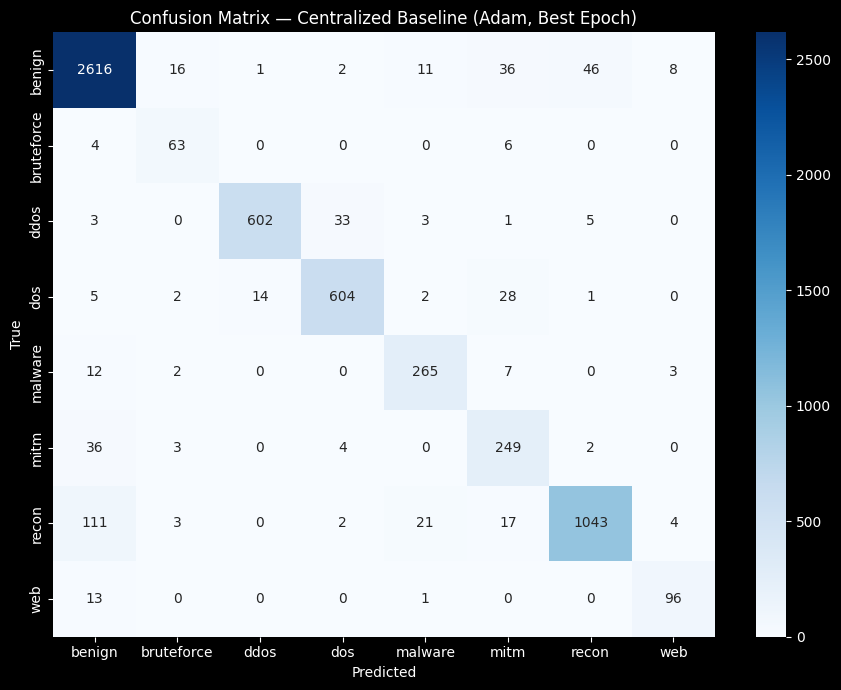


Total test samples: 6006
Correct predictions: 5538 (92.21%)


In [5]:
# Recreate the centralized model for evaluation
# We need to prepare the test data the same way baselines.py does
X_all, y_all, _ = load_processed_data(DATA_PATH)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)
X_train_scaled, X_test_scaled, _ = apply_scaler(X_train_raw, X_test_raw)

# Train a model with the winning config to get a live model for metrics
# (The centralized results dict stores metrics but not the full model object)
from baselines import _train_model
model = create_model(device=DEVICE)
_, best_state = _train_model(
    model, X_train_scaled, y_train, X_test_scaled, y_test,
    epochs=100, lr=0.001, batch_size=64, device=DEVICE,
    verbose=False, label="CM", optimizer_type="adam",
)
set_model_params(model, best_state["model_params"])
print(f"Trained model — best F1: {best_state['f1_macro']:.4f} at epoch {best_state['epoch']}")

cm = compute_confusion_matrix(model, X_test_scaled, y_test, device=DEVICE)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Centralized Baseline (Adam, Best Epoch)")
plt.tight_layout()
plt.show()

print(f"\nTotal test samples: {cm.sum()}")
print(f"Correct predictions: {np.trace(cm)} ({np.trace(cm)/cm.sum():.2%})")

---
## Step 2 — ROC-AUC (Proposal Requirement)

ROC-AUC measures how well the model discriminates each class from all
others across all classification thresholds. A score of 1.0 is perfect;
0.5 is random chance. This is listed as a required metric in the proposal.

Macro ROC-AUC: 0.9909

Per-class ROC-AUC:
  benign      : 0.9785
  bruteforce  : 0.9964
  ddos        : 0.9989
  dos         : 0.9960
  malware     : 0.9911
  mitm        : 0.9864
  recon       : 0.9839
  web         : 0.9964


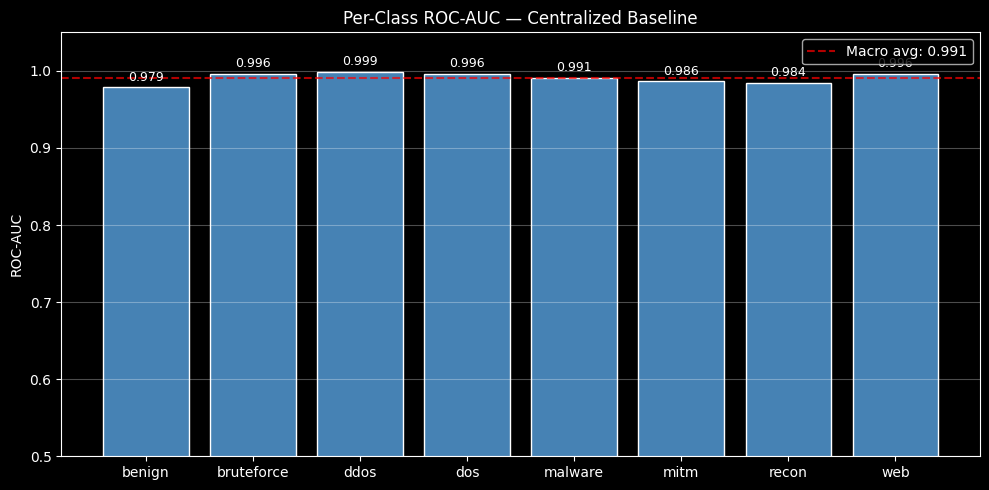

In [6]:
auc_macro, auc_per_class = compute_roc_auc(model, X_test_scaled, y_test, device=DEVICE)

print(f"Macro ROC-AUC: {auc_macro:.4f}")
print(f"\nPer-class ROC-AUC:")
for name, auc in zip(CLASS_NAMES, auc_per_class):
    print(f"  {name:<12}: {auc:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, auc_per_class, color="steelblue", edgecolor="white")
for bar, val in zip(bars, auc_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(y=auc_macro, color="red", linestyle="--", alpha=0.7,
           label=f"Macro avg: {auc_macro:.3f}")
ax.set_ylabel("ROC-AUC")
ax.set_title("Per-Class ROC-AUC — Centralized Baseline")
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3 — Full Classification Report

Generates the per-class precision/recall/F1/support table that goes
directly into the thesis. Includes macro and weighted averages.

In [7]:
report = full_classification_report(
    model, X_test_scaled, y_test, label_names=CLASS_NAMES, device=DEVICE
)

print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 55)
for name in CLASS_NAMES:
    r = report[name]
    print(f"{name:<12} {r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1-score']:>10.4f} {r['support']:>10.0f}")
print("-" * 55)
for avg_type in ["macro avg", "weighted avg"]:
    r = report[avg_type]
    print(f"{avg_type:<12} {r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1-score']:>10.4f} {r['support']:>10.0f}")

Class         Precision     Recall         F1    Support
-------------------------------------------------------
benign           0.9343     0.9561     0.9451       2736
bruteforce       0.7079     0.8630     0.7778         73
ddos             0.9757     0.9304     0.9525        647
dos              0.9364     0.9207     0.9285        656
malware          0.8746     0.9170     0.8953        289
mitm             0.7238     0.8469     0.7806        294
recon            0.9508     0.8684     0.9077       1201
web              0.8649     0.8727     0.8688        110
-------------------------------------------------------
macro avg        0.8710     0.8969     0.8820       6006
weighted avg     0.9251     0.9221     0.9227       6006


---
## Step 4 — Save/Load Results (Reproducibility)

All experiment results are saved as JSON files so they can be:
- Reloaded for analysis without re-running experiments
- Shared with your supervisor or attached as supplementary material
- Version-controlled alongside your code

In [8]:
# Save centralized results
cent_path = save_results(cent_results, f"{RESULTS_DIR}/centralized_adam_100ep.json", overwrite=True)
print(f"Saved centralized results to: {cent_path}")

# Save FL results
fl_path = save_results(fl_results, f"{RESULTS_DIR}/fl_iid_K5_R20_demo.json", overwrite=True)
print(f"Saved FL results to: {fl_path}")

# Verify round-trip
loaded = load_results(cent_path)
print(f"\nRound-trip check:")
print(f"  Original F1: {cent_results['final_metrics']['f1_macro']:.4f}")
print(f"  Loaded F1:   {loaded['final_metrics']['f1_macro']:.4f}")
print(f"  Match: {abs(cent_results['final_metrics']['f1_macro'] - loaded['final_metrics']['f1_macro']) < 1e-6}")

Saved centralized results to: ../results/centralized_adam_100ep.json
Saved FL results to: ../results/fl_iid_K5_R20_demo.json

Round-trip check:
  Original F1: 0.8729
  Loaded F1:   0.8729
  Match: True


---
## Step 5 — Communication Cost Analysis

Quantifies how much network bandwidth FL requires. The proposal lists
"total bytes exchanged and rounds-to-target accuracy" as a required output.

Key metric: **bytes per F1 point** — how efficiently does communication
translate into detection capability.

Communication Cost Summary
Total rounds:         20
Total bytes:          8,864,000
Total MB:             8.45
Avg bytes/round:      443,200
Final F1:             0.7105
Bytes per F1 point:   12,475,195


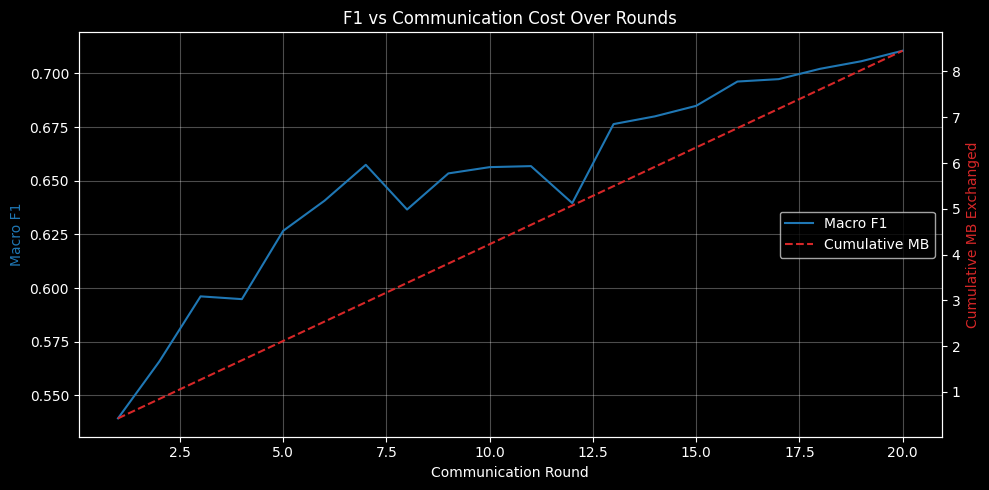

In [9]:
comm = comm_cost_summary(fl_results)

print("Communication Cost Summary")
print("=" * 50)
print(f"Total rounds:         {comm['total_rounds']}")
print(f"Total bytes:          {comm['total_bytes']:,}")
print(f"Total MB:             {comm['total_mb']:.2f}")
print(f"Avg bytes/round:      {comm['bytes_per_round']:,.0f}")
print(f"Final F1:             {comm['final_f1']:.4f}")
print(f"Bytes per F1 point:   {comm['bytes_per_f1_point']:,.0f}")

# Plot cumulative communication cost vs F1
f1s = [r["f1_macro"] for r in fl_results["history"]]
cum_mb = [b / (1024*1024) for b in comm["cumulative_bytes"]]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(range(1, len(f1s)+1), f1s, color="tab:blue", linewidth=1.5, label="Macro F1")
ax2.plot(range(1, len(cum_mb)+1), cum_mb, color="tab:red", linewidth=1.5, linestyle="--", label="Cumulative MB")

ax1.set_xlabel("Communication Round")
ax1.set_ylabel("Macro F1", color="tab:blue")
ax2.set_ylabel("Cumulative MB Exchanged", color="tab:red")
ax1.set_title("F1 vs Communication Cost Over Rounds")
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

---
## Step 6 — Convergence Analysis

In [10]:
conv = convergence_summary(fl_results)

print("Convergence Analysis (FL)")
print("=" * 50)
print(f"Total rounds:               {conv['n_rounds_or_epochs']}")
print(f"Final F1:                   {conv['final_f1']:.4f}")
print(f"Best F1:                    {conv['best_f1']:.4f} (round {conv['best_round']})")
print(f"Improvement in last 10%:    {conv['f1_improvement_last_10pct']:.4f}")
print(f"Converged:                  {conv['converged']}")

# Same for centralized
conv_cent = convergence_summary(cent_results)
print(f"\nConvergence Analysis (Centralized)")
print("=" * 50)
print(f"Total epochs:               {conv_cent['n_rounds_or_epochs']}")
print(f"Final F1:                   {conv_cent['final_f1']:.4f}")
print(f"Best F1:                    {conv_cent['best_f1']:.4f} (epoch {conv_cent['best_round']})")
print(f"Converged:                  {conv_cent['converged']}")

Convergence Analysis (FL)
Total rounds:               20
Final F1:                   0.7105
Best F1:                    0.7105 (round 20)
Improvement in last 10%:    0.0084
Converged:                  False

Convergence Analysis (Centralized)
Total epochs:               100
Final F1:                   0.8729
Best F1:                    0.8846 (epoch 98)
Converged:                  False


---
## Step 7 — Rounds-to-Target Analysis

How many FL rounds are needed to reach 90% and 95% of centralized F1?
This directly answers the communication efficiency question from the proposal.

In [11]:
cent_f1 = cent_results.get("best_metrics", cent_results["final_metrics"])["f1_macro"]

rtt_90 = rounds_to_target(fl_results, centralized_f1=cent_f1, target_fraction=0.90)
rtt_95 = rounds_to_target(fl_results, centralized_f1=cent_f1, target_fraction=0.95)

print(f"Centralized best F1: {cent_f1:.4f}")
print(f"\n90% target ({rtt_90['target_f1']:.4f}):")
print(f"  Reached: {rtt_90['reached']}")
if rtt_90['reached']:
    print(f"  Rounds needed: {rtt_90['rounds_needed']}")
else:
    print(f"  Gap from target: {rtt_90['gap_from_target']:.4f}")

print(f"\n95% target ({rtt_95['target_f1']:.4f}):")
print(f"  Reached: {rtt_95['reached']}")
if rtt_95['reached']:
    print(f"  Rounds needed: {rtt_95['rounds_needed']}")
else:
    print(f"  Gap from target: {rtt_95['gap_from_target']:.4f}")

Centralized best F1: 0.8846

90% target (0.7961):
  Reached: False
  Gap from target: 0.0856

95% target (0.8403):
  Reached: False
  Gap from target: 0.1298


---
## Step 8 — Comparison Table

Side-by-side view of centralized, local-only, ensemble, and FL.
This is the table format for Chapter 4/5 of the thesis.

In [12]:
experiments = {
    "Centralized": cent_results,
    "Local-Only (avg)": {"final_metrics": local_results["avg_metrics"],
                         "total_time_sec": local_results["total_time_sec"]},
    "Ensemble": {"final_metrics": local_results["ensemble_metrics"]},
    "FedAvg IID K5 R20": fl_results,
}

print("=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print_comparison_table(experiments)

COMPARISON TABLE
           Method  Accuracy  F1 (macro)  Precision  Recall  Comm (MB)  Time (s)
-------------------------------------------------------------------------------
      Centralized    0.9177      0.8729     0.8647  0.8869          —     109.7
 Local-Only (avg)    0.7710      0.6599     0.6451  0.7543          —      57.1
         Ensemble    0.7920      0.6827     0.6636  0.7707          —         —
FedAvg IID K5 R20    0.8020      0.7105     0.6869  0.7962       8.45      78.9


---
## Step 9 — Multi-Seed Aggregation Demo

The proposal requires running each experiment with 3 seeds and reporting
mean ± std. This demonstrates the aggregation on 2 quick centralized runs.

In [13]:
# Run centralized with 2 different seeds (short, just for demo)
# In the real experiments, use 3 seeds and full epoch counts
seed_results = []
for seed in [42, 123]:
    res = run_centralized(
        data_path=DATA_PATH, epochs=20, lr=0.001, batch_size=64,
        optimizer_type="adam", device=DEVICE, seed=seed, verbose=False,
    )
    seed_results.append(res)
    print(f"Seed {seed}: F1={res['final_metrics']['f1_macro']:.4f}")

# Aggregate
agg = aggregate_seeds(seed_results)

print(f"\nAggregated (n={agg['n_seeds']} seeds):")
for key, val in agg["final_metrics"].items():
    if isinstance(val, dict) and "mean" in val:
        if isinstance(val["mean"], list):
            print(f"  {key}: [per-class means]")
        else:
            print(f"  {key}: {val['mean']:.4f} ± {val['std']:.4f}")

Seed 42: F1=0.8243
Seed 123: F1=0.8155

Aggregated (n=2 seeds):
  accuracy: 0.8827 ± 0.0054
  f1_macro: 0.8199 ± 0.0044
  precision_macro: 0.7995 ± 0.0050
  recall_macro: 0.8626 ± 0.0016
  per_class_f1: [per-class means]


---
## Step 10 — Statistical Significance Testing

Paired t-test between two configurations using the same seeds.
This is required by the proposal: "Statistical significance tests
(e.g., paired t-tests) comparing different FL configurations."

In [14]:
# Run a second config with same seeds for comparison
seed_results_b = []
for seed in [42, 123]:
    res = run_centralized(
        data_path=DATA_PATH, epochs=20, lr=0.001, batch_size=64,
        optimizer_type="sgd", device=DEVICE, seed=seed, verbose=False,
    )
    seed_results_b.append(res)
    print(f"SGD Seed {seed}: F1={res['final_metrics']['f1_macro']:.4f}")

# Paired t-test: Adam vs SGD
test = pairwise_significance(seed_results, seed_results_b, metric="f1_macro")

print(f"\nPaired t-test: Adam vs SGD")
print(f"  Adam mean F1:  {test['mean_a']:.4f}")
print(f"  SGD mean F1:   {test['mean_b']:.4f}")
print(f"  Difference:    {test['diff']:.4f}")
print(f"  t-statistic:   {test['t_statistic']:.4f}")
print(f"  p-value:       {test['p_value']:.4f}")
print(f"  Significant:   {test['significant']} (p < 0.05)")
if 'note' in test:
    print(f"  Note: {test['note']}")

SGD Seed 42: F1=0.5743
SGD Seed 123: F1=0.6091

Paired t-test: Adam vs SGD
  Adam mean F1:  0.8199
  SGD mean F1:   0.5917
  Difference:    0.2281
  t-statistic:   10.4774
  p-value:       0.0606
  Significant:   False (p < 0.05)


---
## Summary

### What was verified

| Test | Status |
|------|--------|
| Confusion matrix computation | ✓ |
| ROC-AUC (one-vs-rest, multiclass) | ✓ |
| Full classification report | ✓ |
| Save/load JSON round-trip | ✓ |
| Communication cost analysis | ✓ |
| Convergence detection | ✓ |
| Rounds-to-target analysis | ✓ |
| Comparison table generation | ✓ |
| Multi-seed aggregation (mean ± std) | ✓ |
| Paired t-test significance testing | ✓ |

### Proposal coverage

| Proposal requirement | Module function |
|---------------------|----------------|
| Accuracy, F1, precision, recall | `federated.evaluate_model` + `full_classification_report` |
| ROC-AUC | `compute_roc_auc` |
| Convergence plots | `convergence_summary` + notebook plotting |
| Communication cost (bytes, rounds-to-target) | `comm_cost_summary` + `rounds_to_target` |
| Statistical significance tests | `pairwise_significance` |
| Multi-seed reporting (mean ± std) | `aggregate_seeds` |
| Reproducible results storage | `save_results` / `load_results` |

### Output file
- `src/metrics.py` — ready for use by `experiments.py`

### Next step
→ **Experiment runner** (`experiments.py`): Loop over the full experiment
  grid from the proposal, save all results, produce thesis tables.